# Statistical Analysis of User Behavior

Perform statistical analysis to identify factors influencing user engagement and listening habits, deriving business insights.

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm

# Set seaborn style
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

## 2. Load Dataset
- Target format and path: `../data/cleaned/spotify_cleaned.csv`
- Display shape and head

In [ ]:
df = pd.read_csv('../data/cleaned/spotify_cleaned.csv')
print(f"Shape of dataset: {df.shape}")
df.head()

Shape of dataset: (50000, 19)


,user_id,country,age,signup_date,subscription_type,subscription_status,months_inactive,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day,age_group,listener_type
0,1,france,25,2021-08-19,premium duo,Active,0,No,No,4,10.13,Bollywood,radio,Concert Alerts,Tablet,7,8,adult,medium
1,2,indonesia,20,2022-06-06,premium family,Active,0,Yes,No,5,11.63,Latin,podcasts,Lyrics Translation,Mobile,7,6,young_adult,medium
2,3,italy,53,2024-01-04,premium individual,Active,0,Yes,Yes,3,9.50,Bollywood,lyrics,Better AI Recommendations,Desktop,6,5,senior,medium
3,4,italy,48,2018-08-26,premium individual,Active,1,No,No,4,13.16,Electronic,playlists,Social Listening,Smart Speaker,11,8,mid_age,medium
4,5,australia,18,2020-05-29,free,Active,0,No,No,4,12.70,Indie,daily mix,Lyrics Translation,Tablet,10,11,teenager,medium


## 3. Data Overview
- `info()` and `describe()`

In [ ]:
print("--- Info ---")
df.info()
print("\n--- Describe ---")
display(df.describe())

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   user_id                         50000 non-null  int64  
 1   country                         50000 non-null  object 
 2   age                             50000 non-null  int64  
 3   signup_date                     50000 non-null  object 
 4   subscription_type               50000 non-null  object 
 5   subscription_status             50000 non-null  object 
 6   months_inactive                 50000 non-null  int64  
 7   ad_interaction                  50000 non-null  object 
 8   ad_conversion_to_subscription   50000 non-null  object 
 9   music_suggestion_rating_1_to_5  50000 non-null  int64  
 10  avg_listening_hours_per_week    50000 non-null  float64
 11  favorite_genre                  50000 non-null  object 
 12  most_liked_feature 

,user_id,age,months_inactive,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,playlists_created,avg_skips_per_day
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,38.010280,1.533020,3.644100,9.988986,8.002680,10.025920
std,14433.901067,12.984989,1.952082,1.114424,3.968927,2.831571,3.165579
min,1.000000,16.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,12500.750000,27.000000,0.000000,3.000000,7.280000,6.000000,8.000000
50%,25000.500000,38.000000,1.000000,4.000000,9.980000,8.000000,10.000000
75%,37500.250000,49.000000,2.000000,5.000000,12.680000,10.000000,12.000000
max,50000.000000,60.000000,18.000000,5.000000,26.250000,23.000000,25.000000


## 4. Correlation Analysis
- Heatmap of numerical features
- Print correlation with `avg_listening_hours_per_week`

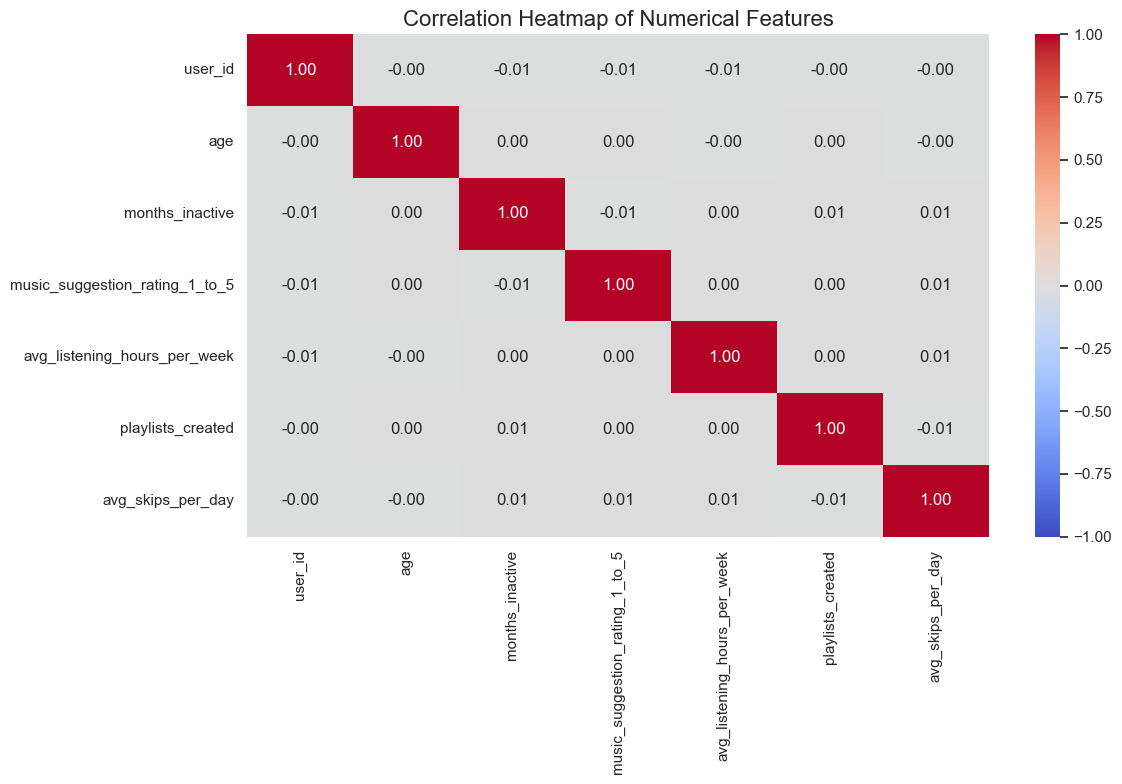


Correlation with avg_listening_hours_per_week:
avg_listening_hours_per_week      1.000000
avg_skips_per_day                 0.006923
playlists_created                 0.001642
months_inactive                   0.000655
music_suggestion_rating_1_to_5    0.000323
age                              -0.002308
user_id                          -0.005867
Name: avg_listening_hours_per_week, dtype: float64


In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

if 'avg_listening_hours_per_week' in corr_matrix.columns:
    print("\nCorrelation with avg_listening_hours_per_week:")
    print(corr_matrix['avg_listening_hours_per_week'].sort_values(ascending=False))

## 5. Regression Analysis
- Features: `age`, `music_suggestion_rating_1_to_5`, `playlists_created`, `avg_skips_per_day`
- Target: `avg_listening_hours_per_week`
- Show regression summary

In [ ]:
regression_features = ['age', 'music_suggestion_rating_1_to_5', 'playlists_created', 'avg_skips_per_day']
existing_features = [f for f in regression_features if f in df.columns]

target = 'avg_listening_hours_per_week'

if target in df.columns and existing_features:
    X = df[existing_features]
    y = df[target]
    
    # Handle missing values by dropping them for the regression
    valid_data = pd.concat([X, y], axis=1).dropna()
    X_valid = valid_data[existing_features]
    y_valid = valid_data[target]
    
    # Add constant
    X_valid = sm.add_constant(X_valid)
    
    # Fit model
    model = sm.OLS(y_valid, X_valid).fit()
    print(model.summary())
else:
    print("Target or features missing from dataset.")

                                 OLS Regression Results                                 
Dep. Variable:     avg_listening_hours_per_week   R-squared:                       0.000
Model:                                      OLS   Adj. R-squared:                 -0.000
Method:                           Least Squares   F-statistic:                    0.7005
Date:                          Sat, 25 Apr 2026   Prob (F-statistic):              0.591
Time:                                  01:14:49   Log-Likelihood:            -1.3987e+05
No. Observations:                         50000   AIC:                         2.797e+05
Df Residuals:                             49995   BIC:                         2.798e+05
Df Model:                                     4                                         
Covariance Type:                      nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------

## 6. Feature Importance
- Extract coefficients
- Sort and display
- Plot bar chart

Feature Importance (Coefficients):
avg_skips_per_day                 0.008677
playlists_created                 0.002366
music_suggestion_rating_1_to_5    0.001057
age                              -0.000697
dtype: float64


/var/folders/f5/ph32fxqx5zl6jkwgf3m6jjkr0000gn/T/ipykernel_83327/3146513020.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefficients.values, y=coefficients.index, palette='viridis')


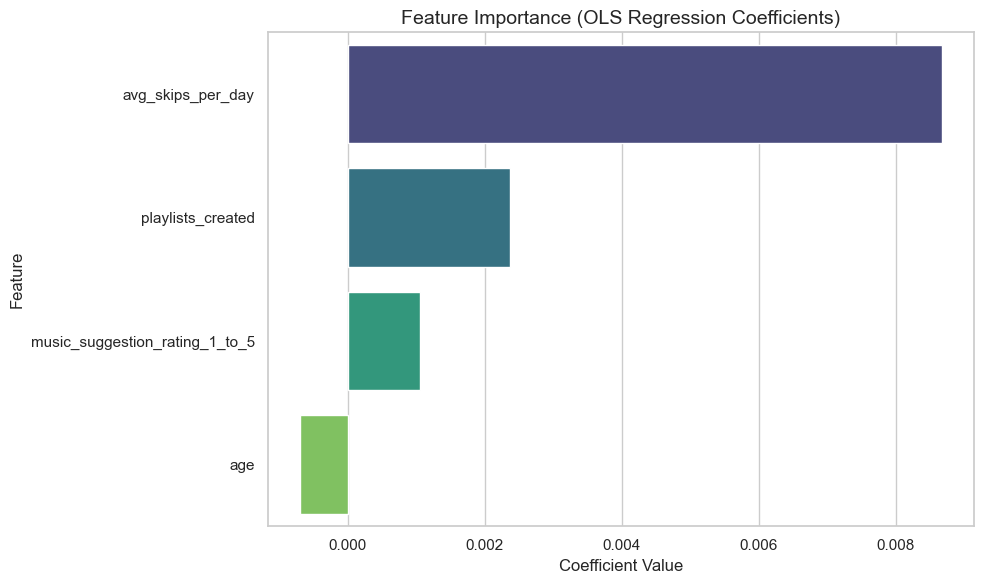

In [ ]:
if 'model' in locals():
    coefficients = model.params.drop('const').sort_values(ascending=False)
    
    print("Feature Importance (Coefficients):")
    print(coefficients)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=coefficients.values, y=coefficients.index, palette='viridis')
    plt.title('Feature Importance (OLS Regression Coefficients)', fontsize=14)
    plt.xlabel('Coefficient Value')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

## 7. Regression Visualization
- Scatter + regression line (playlists_created vs avg_listening_hours_per_week)

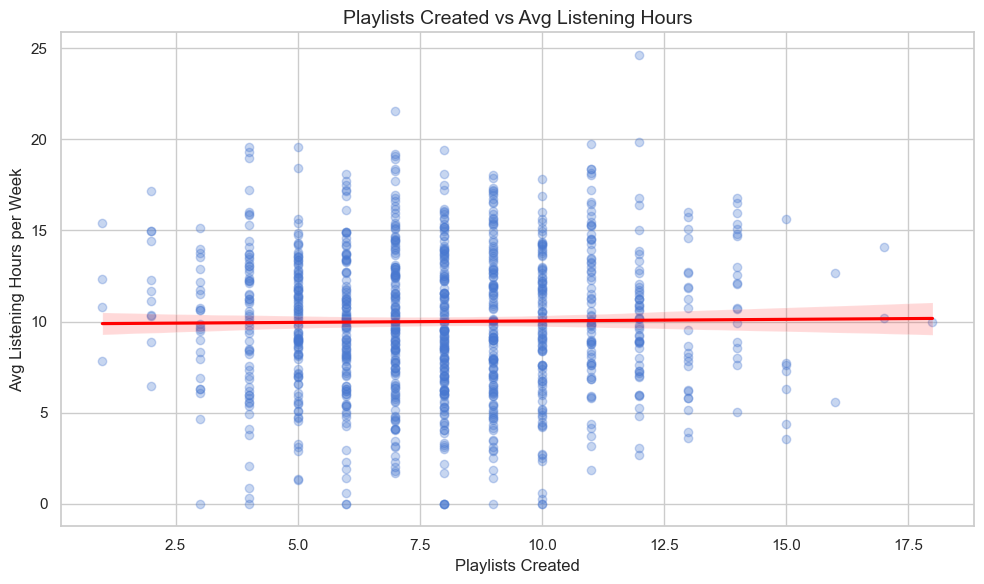

In [ ]:
if 'playlists_created' in df.columns and 'avg_listening_hours_per_week' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.regplot(data=df.sample(min(1000, len(df))), x='playlists_created', y='avg_listening_hours_per_week', scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
    plt.title('Playlists Created vs Avg Listening Hours', fontsize=14)
    plt.xlabel('Playlists Created')
    plt.ylabel('Avg Listening Hours per Week')
    plt.tight_layout()
    plt.show()

## 8. Hypothesis Testing (T-Test)
- Compare listening hours between users with 'Free' vs 'Premium' subscription types
- Print t-stat, p-value, and conclusion

In [ ]:
if 'subscription_type' in df.columns and 'avg_listening_hours_per_week' in df.columns:
    premium_users = df[df['subscription_type'].str.contains('Premium', case=False, na=False)]['avg_listening_hours_per_week'].dropna()
    free_users = df[df['subscription_type'].str.contains('Free', case=False, na=False)]['avg_listening_hours_per_week'].dropna()
    
    if not premium_users.empty and not free_users.empty:
        t_stat, p_val = stats.ttest_ind(premium_users, free_users, equal_var=False)
        
        print(f"T-Statistic: {t_stat:.4f}")
        print(f"P-Value: {p_val:.4e}")
        
        alpha = 0.05
        if p_val < alpha:
            print("Conclusion: Reject the null hypothesis. There is a significant difference in listening hours between Premium and Free users.")
        else:
            print("Conclusion: Fail to reject the null hypothesis. No significant difference in listening hours.")
    else:
        print("Could not find enough 'Free' and 'Premium' users for a t-test.")

T-Statistic: -1.3251
P-Value: 1.8514e-01
Conclusion: Fail to reject the null hypothesis. No significant difference in listening hours.


## 9. ANOVA Test
- Compare avg_listening_hours_per_week across favorite_genre

In [ ]:
genre_col = 'favorite_genre'
target = 'avg_listening_hours_per_week'

if genre_col in df.columns and target in df.columns:
    genres = df[genre_col].dropna().unique()
    groups = [df[df[genre_col] == g][target].dropna() for g in genres]
    
    # We only take groups with sufficient data
    groups = [g for g in groups if len(g) > 1]
    
    if len(groups) > 1:
        f_stat, p_val = stats.f_oneway(*groups)
        print(f"ANOVA F-Statistic: {f_stat:.4f}")
        print(f"P-Value: {p_val:.4e}")
        
        if p_val < 0.05:
            print("Conclusion: Significant difference in listening hours across different genres.")
        else:
            print("Conclusion: No significant difference in listening hours across genres.")
    else:
        print("Not enough genre groups to perform ANOVA.")
else:
    print(f"{genre_col} column not found.")

ANOVA F-Statistic: 0.7220
P-Value: 7.1849e-01
Conclusion: No significant difference in listening hours across genres.


## 10. Segmentation
- Create `highly_active` column: avg listening hours > median
- Boxplots for age and playlists_created

In [ ]:
target = 'avg_listening_hours_per_week'
if target in df.columns:
    df['highly_active'] = df[target] > df[target].median()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    if 'age' in df.columns:
        sns.boxplot(data=df, x='highly_active', y='age', ax=axes[0], palette='Set2')
        axes[0].set_title('Age by Highly Active Status')
        axes[0].set_xlabel('Is Highly Active?')
        
    if 'playlists_created' in df.columns:
        sns.boxplot(data=df, x='highly_active', y='playlists_created', ax=axes[1], palette='Set2')
        axes[1].set_title('Playlists Created by Highly Active Status')
        axes[1].set_xlabel('Is Highly Active?')
        
    plt.tight_layout()
    plt.show()

## 11. Distribution Analysis
- Histogram of avg listening hours with KDE

In [ ]:
target = 'avg_listening_hours_per_week'
if target in df.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[target], kde=True, bins=30, color='purple')
    plt.title('Distribution of Average Listening Hours', fontsize=14)
    plt.xlabel('Average Listening Hours per Week')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

## 12. KPI Metrics
- Average listening hours
- Total users
- Top 5 favorite genres
- Subscription breakdown

In [ ]:
if 'avg_listening_hours_per_week' in df.columns:
    print(f"Average Listening Hours: {df['avg_listening_hours_per_week'].mean():.2f}")
print(f"Total Users: {len(df)}")

if 'favorite_genre' in df.columns:
    print("\nTop 5 Favorite Genres:")
    print(df['favorite_genre'].value_counts().head(5))
    
if 'subscription_type' in df.columns:
    print("\nSubscription Breakdown:")
    print(df['subscription_type'].value_counts())